# Statistical Learning

**Scenario:**  
You are a data analyst at a university. The academic team collected data on 400 students and wants to understand: _"What factors drive exam scores?"_

You have **7 variables** per student:

| Column | Type | Description |
|---|---|---|
| `study_hours` | Continuous | Weekly study hours outside class |
| `sleep_hours` | Continuous | Average nightly sleep |
| `attendance_pct` | Continuous | % of classes attended (0–100) |
| `previous_gpa` | Continuous | GPA from previous semester (0–4.0) |
| `stress_level` | Ordinal | Self-reported stress 1 (low) – 10 (high) |
| `resources_used` | Discrete | # of academic resources used (tutoring, library…) |
| `exam_score` | Continuous | Final exam score (0–100) ← **TARGET** |

**You do NOT build a model yet.** First, you understand the data statistically.

---
## 0. Setup

In [2]:
# Uncomment the line below only the first time you run this notebook:
# !pip install pandas numpy matplotlib seaborn scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
np.random.seed(42)

print('Ready.')

Ready.


---
## 1. Build the Dataset

We generate 400 student records with **realistic distributions and realistic correlations**.

> Reading the generation code teaches you something important: real data always comes from a mix of signal (real relationships) + noise (randomness we cannot control).

In [3]:
N = 400

# --- Features ---
study_hours    = np.random.normal(loc=6.0, scale=2.5, size=N).clip(0, 15).round(1)
sleep_hours    = np.random.normal(loc=6.8, scale=1.2, size=N).clip(3, 10).round(1)
attendance_pct = np.random.normal(loc=75,  scale=15,  size=N).clip(20, 100).round(1)
previous_gpa   = np.random.normal(loc=2.8, scale=0.6, size=N).clip(0, 4.0).round(2)
stress_level   = np.random.randint(1, 11, size=N)          # integer 1–10
resources_used = np.random.poisson(lam=3, size=N).clip(0, 10)  # count variable

# --- Target: exam_score is driven by the features above + noise ---
noise = np.random.normal(0, 5, N)

exam_score = (
    30                           # base score everyone gets
    + 3.0  * study_hours         # more study  → higher score
    + 1.5  * sleep_hours         # more sleep  → slightly higher
    + 0.25 * attendance_pct      # attending class helps
    + 6.0  * previous_gpa        # strong prior GPA → strong exam
    - 1.2  * stress_level        # stress hurts performance
    + 1.0  * resources_used      # using resources helps
    + noise
).clip(0, 100).round(1)

# --- Assemble DataFrame ---
df = pd.DataFrame({
    'study_hours':    study_hours,
    'sleep_hours':    sleep_hours,
    'attendance_pct': attendance_pct,
    'previous_gpa':   previous_gpa,
    'stress_level':   stress_level,
    'resources_used': resources_used,
    'exam_score':     exam_score
})

# Inject 4% missing values in attendance_pct (students skipped the survey)
missing_idx = np.random.choice(df.index, size=16, replace=False)
df.loc[missing_idx, 'attendance_pct'] = np.nan

print(f'Dataset: {df.shape[0]} students × {df.shape[1]} columns')
df.head(10)

Dataset: 400 students × 7 columns


,study_hours,sleep_hours,attendance_pct,previous_gpa,stress_level,resources_used,exam_score
0,7.2,4.9,89.1,2.88,10,3,84.4
1,5.7,6.1,67.3,2.54,3,3,92.4
2,7.6,6.8,76.4,2.87,3,3,97.5
3,9.8,6.9,68.1,3.13,1,1,100.0
4,5.4,6.3,68.5,2.83,7,3,81.2
5,5.4,7.5,70.4,2.82,5,4,90.3
6,9.9,5.5,78.3,2.38,4,4,100.0
7,7.9,6.6,67.8,2.40,10,1,82.6
8,4.8,6.9,93.8,1.96,4,3,85.2
9,7.4,7.4,61.6,3.85,4,0,100.0


---
## 2. First Look — Always Do This First

Before any statistics, before any plot — just **look** at the raw data and ask three questions:
1. How big is it?
2. Are there missing values?
3. What do the numbers look like at a glance?

In [4]:
print('── Shape ─────────────────────────────────')
print(f'  {df.shape[0]} rows (students), {df.shape[1]} columns (variables)\n')

print('── Data types ────────────────────────────')
print(df.dtypes.to_string(), '\n')

print('── Missing values ────────────────────────')
missing = df.isnull().sum()
print(missing[missing > 0].to_string() if missing.any() else '  None')
print(f'  ({missing.sum()} total missing cells out of {df.size})\n')

print('── Summary statistics ────────────────────')
df.describe().round(2)

── Shape ─────────────────────────────────
  400 rows (students), 7 columns (variables)

── Data types ────────────────────────────
study_hours       float64
sleep_hours       float64
attendance_pct    float64
previous_gpa      float64
stress_level        int32
resources_used      int32
exam_score        float64 

── Missing values ────────────────────────
attendance_pct    16
  (16 total missing cells out of 2800)

── Summary statistics ────────────────────


,study_hours,sleep_hours,attendance_pct,previous_gpa,stress_level,resources_used,exam_score
count,400.00,400.00,384.00,400.00,400.00,400.00,400.00
mean,6.06,6.75,76.84,2.82,5.43,2.97,89.56
std,2.38,1.20,14.28,0.59,2.81,1.68,9.19
min,0.00,3.60,31.60,1.05,1.00,0.00,59.70
25%,4.38,5.90,67.00,2.41,3.00,2.00,83.75
50%,6.15,6.80,77.75,2.82,5.00,3.00,90.15
75%,7.60,7.50,87.65,3.21,8.00,4.00,98.40
max,15.00,10.00,100.00,4.00,10.00,9.00,100.00


### What `.describe()` tells you — column by column

| Stat | What it answers |
|---|---|
| `count` | How many non-null values? (< N → there are missing values) |
| `mean` | The arithmetic average |
| `std` | How spread out values are (standard deviation) |
| `min` | Smallest value — is it realistic? |
| `25%` | 1st quartile — 25 % of students are below this |
| `50%` | Median — the middle student |
| `75%` | 3rd quartile — 75 % of students are below this |
| `max` | Largest value — is it realistic or an error? |

> **Quick check:** Is `mean` ≈ `50%` (median)? If not, the distribution is skewed.

---
## 3. Descriptive Statistics

### 3.1 Central Tendency — Where is the centre?

Three tools to describe the "typical" student:

| Measure | Definition | Sensitive to outliers? |
|---|---|---|
| **Mean** | Sum ÷ count | YES — one extreme value shifts it |
| **Median** | Middle value when sorted | No |
| **Mode** | Most frequent value | No |

In [5]:
features = ['study_hours', 'sleep_hours', 'attendance_pct',
            'previous_gpa', 'stress_level', 'resources_used', 'exam_score']

print(f"{'Column':>18}   {'Mean':>8}   {'Median':>8}   {'Mode':>8}   {'Mean−Median':>12}")
print('─' * 65)

for col in features:
    m   = df[col].mean()
    med = df[col].median()
    mod = df[col].mode()[0]
    diff = m - med
    print(f"{col:>18}   {m:>8.2f}   {med:>8.2f}   {mod:>8.2f}   {diff:>+12.2f}")

print()
print('Positive Mean−Median → distribution pulled right (right-skewed)')
print('Negative Mean−Median → distribution pulled left  (left-skewed)')
print('Near zero            → roughly symmetric')

            Column       Mean     Median       Mode    Mean−Median
─────────────────────────────────────────────────────────────────
       study_hours       6.06       6.15       6.20          -0.09
       sleep_hours       6.75       6.80       6.90          -0.05
    attendance_pct      76.84      77.75     100.00          -0.91
      previous_gpa       2.82       2.82       4.00          +0.00
      stress_level       5.43       5.00       3.00          +0.43
    resources_used       2.97       3.00       3.00          -0.03
        exam_score      89.56      90.15     100.00          -0.59

Positive Mean−Median → distribution pulled right (right-skewed)
Negative Mean−Median → distribution pulled left  (left-skewed)
Near zero            → roughly symmetric


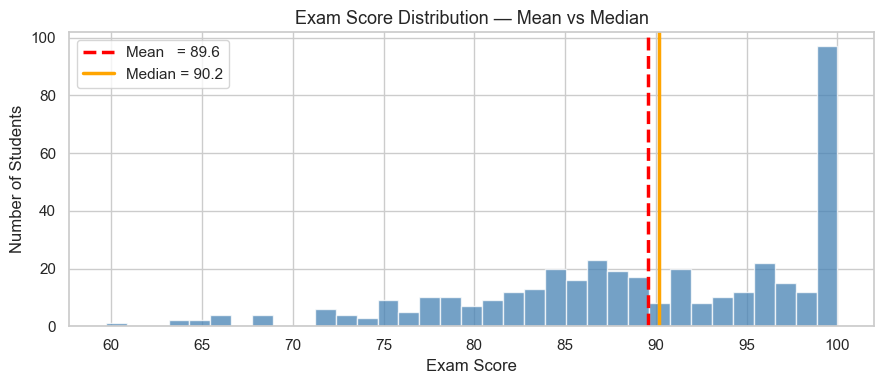

Difference (mean − median) = -0.59
When they are close, data is symmetric.
When they differ, one of them is a better summary — median is safer.


In [6]:
# Visualise mean vs median for exam_score
col = 'exam_score'
mean_val   = df[col].mean()
median_val = df[col].median()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df[col], bins=35, color='steelblue', alpha=0.75, edgecolor='white')
ax.axvline(mean_val,   color='red',    lw=2.5, ls='--', label=f'Mean   = {mean_val:.1f}')
ax.axvline(median_val, color='orange', lw=2.5, ls='-',  label=f'Median = {median_val:.1f}')
ax.set_title('Exam Score Distribution — Mean vs Median', fontsize=13)
ax.set_xlabel('Exam Score')
ax.set_ylabel('Number of Students')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Difference (mean − median) = {mean_val - median_val:+.2f}')
print('When they are close, data is symmetric.')
print('When they differ, one of them is a better summary — median is safer.')

---
### 3.2 Spread — How different are students from each other?

Knowing the centre is not enough. You also need to know how **wide** the data is.

$$\text{Variance} = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

$$\text{Standard Deviation} = \sqrt{\text{Variance}}$$

**Coefficient of Variation (CV)** = std ÷ mean × 100  
→ Spread expressed as a percentage of the mean. Useful to compare columns with different scales.

In [7]:
print(f"{'Column':>18}   {'Mean':>8}   {'Std':>8}   {'Variance':>10}   {'CV %':>8}   {'Range':>8}")
print('─' * 72)

for col in features:
    s  = df[col]
    m  = s.mean()
    sd = s.std()
    v  = s.var()
    cv = (sd / m) * 100
    rng = s.max() - s.min()
    print(f"{col:>18}   {m:>8.2f}   {sd:>8.2f}   {v:>10.2f}   {cv:>7.1f}%   {rng:>8.2f}")

print()
print('CV interpretation:')
print('  < 15%  → low variability  (students are similar on this measure)')
print('  15–35% → moderate')
print('  > 35%  → high variability (students are very different from each other)')

            Column       Mean        Std     Variance       CV %      Range
────────────────────────────────────────────────────────────────────────
       study_hours       6.06       2.38         5.65      39.2%      15.00
       sleep_hours       6.75       1.20         1.45      17.8%       6.40
    attendance_pct      76.84      14.28       204.04      18.6%      68.40
      previous_gpa       2.82       0.59         0.35      21.1%       2.95
      stress_level       5.43       2.81         7.92      51.8%       9.00
    resources_used       2.97       1.68         2.82      56.5%       9.00
        exam_score      89.56       9.19        84.39      10.3%      40.30

CV interpretation:
  < 15%  → low variability  (students are similar on this measure)
  15–35% → moderate
  > 35%  → high variability (students are very different from each other)


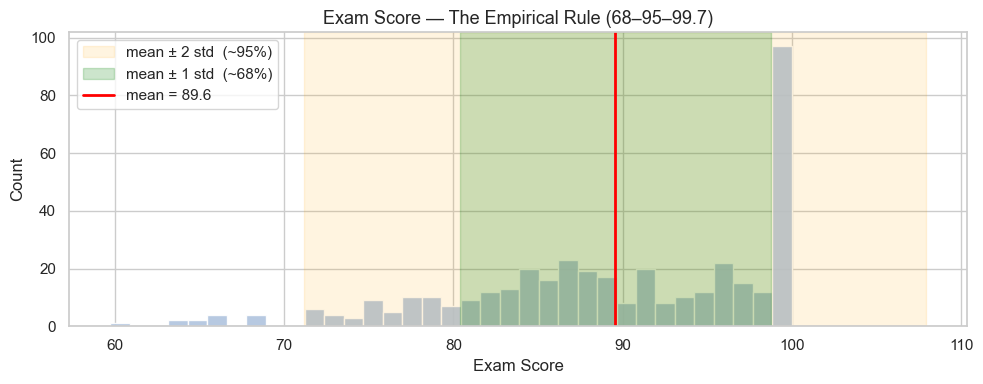

Empirical verification on our data:
  ±1 std: 237 students = 59.2%   (theory ≈ 68%)
  ±2 std: 387 students = 96.8%   (theory ≈ 95%)
  ±3 std: 399 students = 99.8%   (theory ≈ 99.7%)


In [8]:
# Show ±1 and ±2 std bands on exam_score
col = 'exam_score'
m, s = df[col].mean(), df[col].std()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df[col], bins=35, color='lightsteelblue', edgecolor='white', alpha=0.9)

# Shade ±1 and ±2 std bands
ax.axvspan(m - 2*s, m + 2*s, alpha=0.12, color='orange', label='mean ± 2 std  (~95%)')
ax.axvspan(m - s,   m + s,   alpha=0.20, color='green',  label='mean ± 1 std  (~68%)')
ax.axvline(m, color='red', lw=2, label=f'mean = {m:.1f}')

ax.set_title('Exam Score — The Empirical Rule (68–95–99.7)', fontsize=13)
ax.set_xlabel('Exam Score')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

# Check empirically
print('Empirical verification on our data:')
for k, theory in [(1, 68), (2, 95), (3, 99.7)]:
    within = df[col].between(m - k*s, m + k*s).sum()
    pct = within / len(df) * 100
    print(f'  ±{k} std: {within} students = {pct:.1f}%   (theory ≈ {theory}%)')

---
## 4. Distributions — Shape is Everything

Every statistical method has assumptions about shape. Knowing the shape **before** engineering features tells you:
- Which transformations to apply (log, sqrt, binning …)
- Whether outliers are likely to exist
- Whether a column will help a model

**Skewness** = asymmetry  
**Kurtosis** = tail heaviness (excess kurtosis; 0 = normal tails)

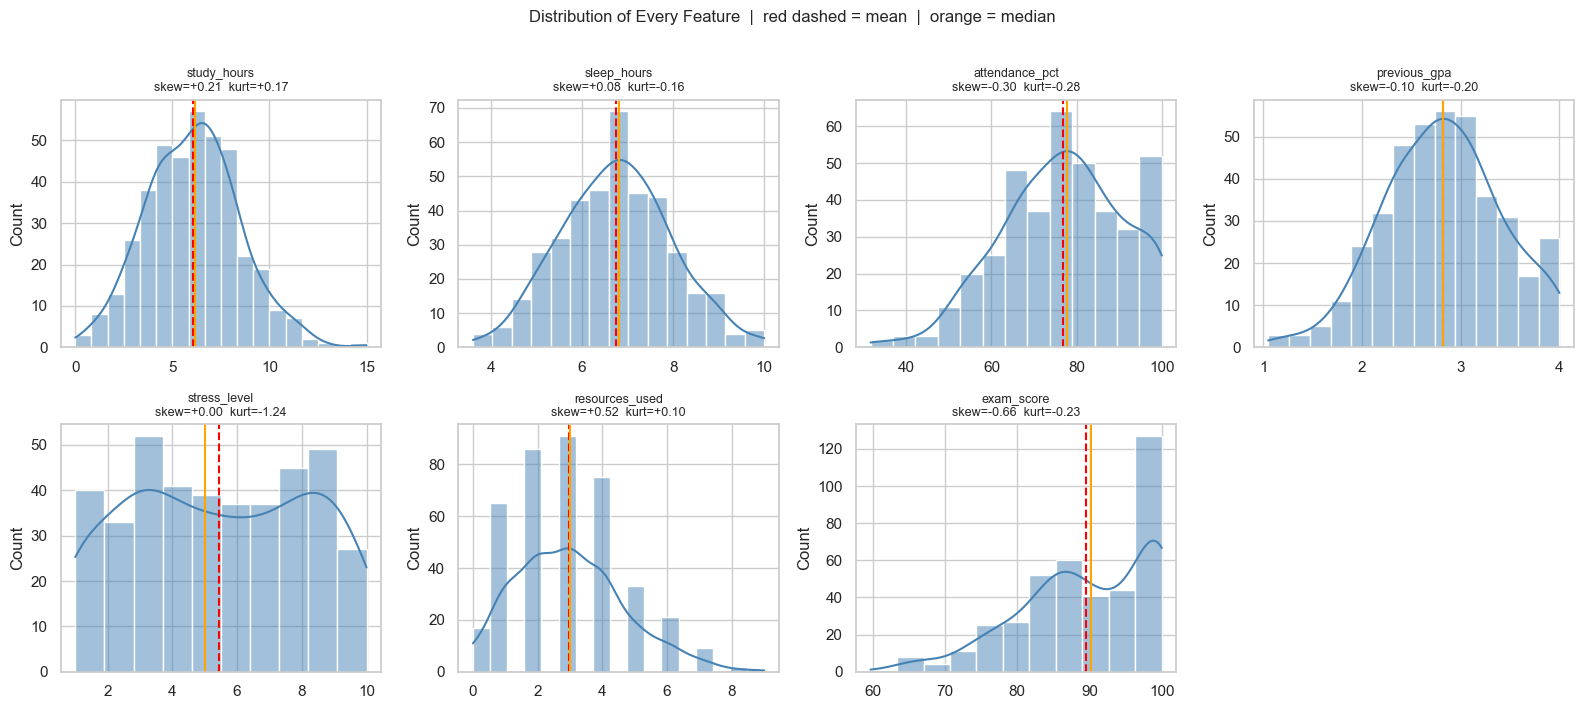

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    sns.histplot(df[col].dropna(), ax=ax, kde=True, color='steelblue', edgecolor='white')
    ax.axvline(df[col].mean(),   color='red',    lw=1.5, ls='--')
    ax.axvline(df[col].median(), color='orange', lw=1.5)
    ax.set_title(f'{col}\nskew={skew:+.2f}  kurt={kurt:+.2f}', fontsize=9)
    ax.set_xlabel('')

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Distribution of Every Feature  |  red dashed = mean  |  orange = median',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# Skewness table with plain-English interpretation
def interpret_skew(sk):
    if abs(sk) < 0.5:  return 'Symmetric'
    elif sk > 1.0:     return 'Strongly right-skewed'
    elif sk > 0.5:     return 'Moderately right-skewed'
    elif sk < -1.0:    return 'Strongly left-skewed'
    else:              return 'Moderately left-skewed'

def interpret_kurt(ku):
    if abs(ku) < 0.5:  return 'Normal-like tails'
    elif ku > 0:       return 'Heavy tails (more extremes)'
    else:              return 'Light tails (fewer extremes)'

print(f"{'Column':>18}   {'Skewness':>10}   {'Kurtosis':>10}   {'Shape':>25}   {'Tails':>25}")
print('─' * 100)
for col in features:
    sk = df[col].skew()
    ku = df[col].kurtosis()
    print(f"{col:>18}   {sk:>+10.3f}   {ku:>+10.3f}   {interpret_skew(sk):>25}   {interpret_kurt(ku):>25}")

print()
print('Feature engineering tip:')
print('  Right-skewed  → consider log(x+1) or sqrt(x) transform')
print('  Left-skewed   → consider squaring or exponential transform')
print('  Symmetric     → usually fine as-is for most models')

            Column     Skewness     Kurtosis                       Shape                       Tails
────────────────────────────────────────────────────────────────────────────────────────────────────
       study_hours       +0.207       +0.167                   Symmetric           Normal-like tails
       sleep_hours       +0.085       -0.163                   Symmetric           Normal-like tails
    attendance_pct       -0.302       -0.282                   Symmetric           Normal-like tails
      previous_gpa       -0.102       -0.204                   Symmetric           Normal-like tails
      stress_level       +0.002       -1.243                   Symmetric   Light tails (fewer extremes)
    resources_used       +0.519       +0.102     Moderately right-skewed           Normal-like tails
        exam_score       -0.659       -0.233      Moderately left-skewed           Normal-like tails

Feature engineering tip:
  Right-skewed  → consider log(x+1) or sqrt(x) transform
  Lef

---
## 5. Outlier Detection

An outlier is a value that is **unusually far from the rest**. They can be:
- Data entry errors (a student recorded `study_hours = 98`)
- Genuine extremes (a student who truly slept 2 hours every night)

Your job at this stage is to **detect and understand** them — not blindly delete them.

### Method 1 — IQR (Interquartile Range)

$$\text{IQR} = Q3 - Q1$$
$$\text{Lower fence} = Q1 - 1.5 \times \text{IQR}$$
$$\text{Upper fence} = Q3 + 1.5 \times \text{IQR}$$

### Method 2 — Z-score

$$z_i = \frac{x_i - \bar{x}}{\sigma}$$

A value with |z| > 3 is more than 3 standard deviations away from the mean.

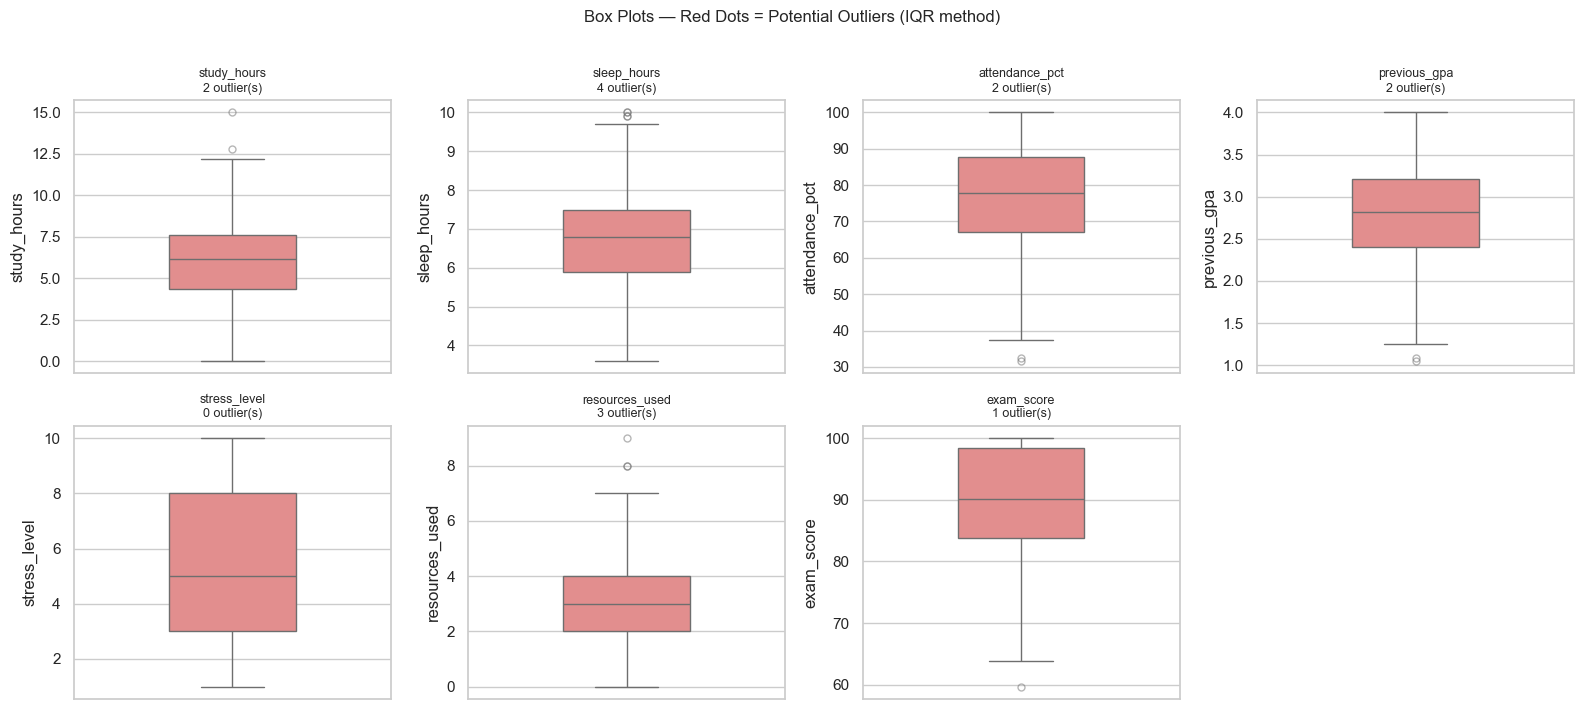

Box anatomy:
  ─── = median
  Box edges = Q1 (25%) and Q3 (75%)
  Whiskers  = Q1−1.5×IQR  to  Q3+1.5×IQR
  Dots      = points outside the whiskers → outlier candidates


In [11]:
# Box plots — visual outlier detection
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    sns.boxplot(y=df[col], ax=ax, color='lightcoral', width=0.4,
                flierprops=dict(marker='o', color='red', alpha=0.5, markersize=5))
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    ax.set_title(f'{col}\n{n_out} outlier(s)', fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Box Plots — Red Dots = Potential Outliers (IQR method)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print('Box anatomy:')
print('  ─── = median')
print('  Box edges = Q1 (25%) and Q3 (75%)')
print('  Whiskers  = Q1−1.5×IQR  to  Q3+1.5×IQR')
print('  Dots      = points outside the whiskers → outlier candidates')

In [12]:
# Numeric outlier report — both methods side-by-side
print(f"{'Column':>18}   {'IQR outliers':>14}   {'Z>3 outliers':>14}   {'Q1':>7}   {'Q3':>7}   {'IQR':>7}")
print('─' * 75)

for col in features:
    series = df[col].dropna()

    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    iqr_out = ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()

    z = np.abs(stats.zscore(series))
    z_out = (z > 3).sum()

    print(f"{col:>18}   {iqr_out:>14}   {z_out:>14}   {Q1:>7.2f}   {Q3:>7.2f}   {IQR:>7.2f}")

print()
print('IQR method: more conservative, detects more outliers')
print('Z-score   : stricter — only flags extreme cases')
print('Use both, then investigate the flagged rows before deciding what to do.')

            Column     IQR outliers     Z>3 outliers        Q1        Q3       IQR
───────────────────────────────────────────────────────────────────────────
       study_hours                2                1      4.38      7.60      3.22
       sleep_hours                4                0      5.90      7.50      1.60
    attendance_pct                2                2     67.00     87.65     20.65
      previous_gpa                2                0      2.41      3.21      0.80
      stress_level                0                0      3.00      8.00      5.00
    resources_used                3                1      2.00      4.00      2.00
        exam_score                1                1     83.75     98.40     14.65

IQR method: more conservative, detects more outliers
Z-score   : stricter — only flags extreme cases
Use both, then investigate the flagged rows before deciding what to do.


In [13]:
# Show the actual outlier rows for study_hours
col = 'study_hours'
Q1  = df[col].quantile(0.25)
Q3  = df[col].quantile(0.75)
IQR = Q3 - Q1
mask = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)

print(f"Outlier rows in '{col}' (IQR method):")
print(f'  Fence: [{Q1 - 1.5*IQR:.1f}, {Q3 + 1.5*IQR:.1f}]  (Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f})')
print()
print(df[mask][['study_hours', 'exam_score']].sort_values('study_hours'))

Outlier rows in 'study_hours' (IQR method):
  Fence: [-0.5, 12.4]  (Q1=4.4, Q3=7.6, IQR=3.2)

     study_hours  exam_score
179         12.8       100.0
209         15.0       100.0


---
## 6. Correlation — Do Features Move with the Target?

Correlation (Pearson r) measures **linear relationship strength**:

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \cdot \sum(y_i-\bar{y})^2}}$$

| r | Strength |
|---|---|
| ±1.0 | Perfect |
| ±0.7–1.0 | Strong |
| ±0.4–0.7 | Moderate |
| ±0.2–0.4 | Weak |
| 0–0.2 | Very weak / none |

> **Correlation ≠ Causation**  
> Sleep hours and exam scores might both be caused by a third variable (student discipline), not by each other directly.

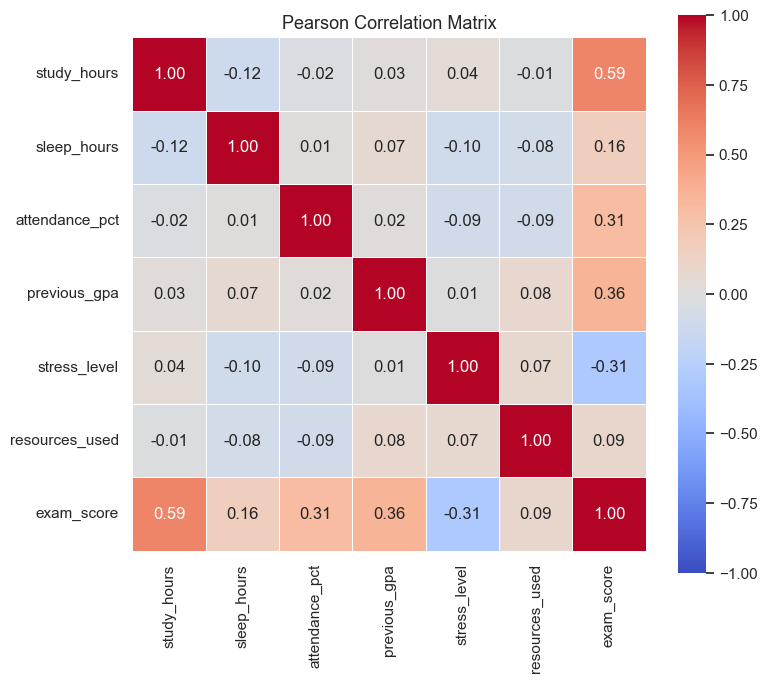

Dark red  = strong positive correlation
Dark blue = strong negative correlation
Pale      = weak or no linear relationship


In [14]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    ax=ax
)
ax.set_title('Pearson Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

print('Dark red  = strong positive correlation')
print('Dark blue = strong negative correlation')
print('Pale      = weak or no linear relationship')

In [15]:
# Focus on correlations with the TARGET (exam_score)
target_corr = corr['exam_score'].drop('exam_score').sort_values(key=abs, ascending=False)

print('Correlation with exam_score (sorted by strength):')
print()
for col, r in target_corr.items():
    bar   = '█' * int(abs(r) * 30)
    sign  = '+' if r >= 0 else '-'
    label = 'positive' if r >= 0 else 'negative'
    print(f"  {col:>18}  r={r:+.3f}  {sign}{bar}  ({label})")

print()
print('The features at the TOP are the most linearly related to exam score.')
print('These are your best starting features for a model.')

Correlation with exam_score (sorted by strength):

         study_hours  r=+0.595  +█████████████████  (positive)
        previous_gpa  r=+0.358  +██████████  (positive)
        stress_level  r=-0.314  -█████████  (negative)
      attendance_pct  r=+0.310  +█████████  (positive)
         sleep_hours  r=+0.165  +████  (positive)
      resources_used  r=+0.088  +██  (positive)

The features at the TOP are the most linearly related to exam score.
These are your best starting features for a model.


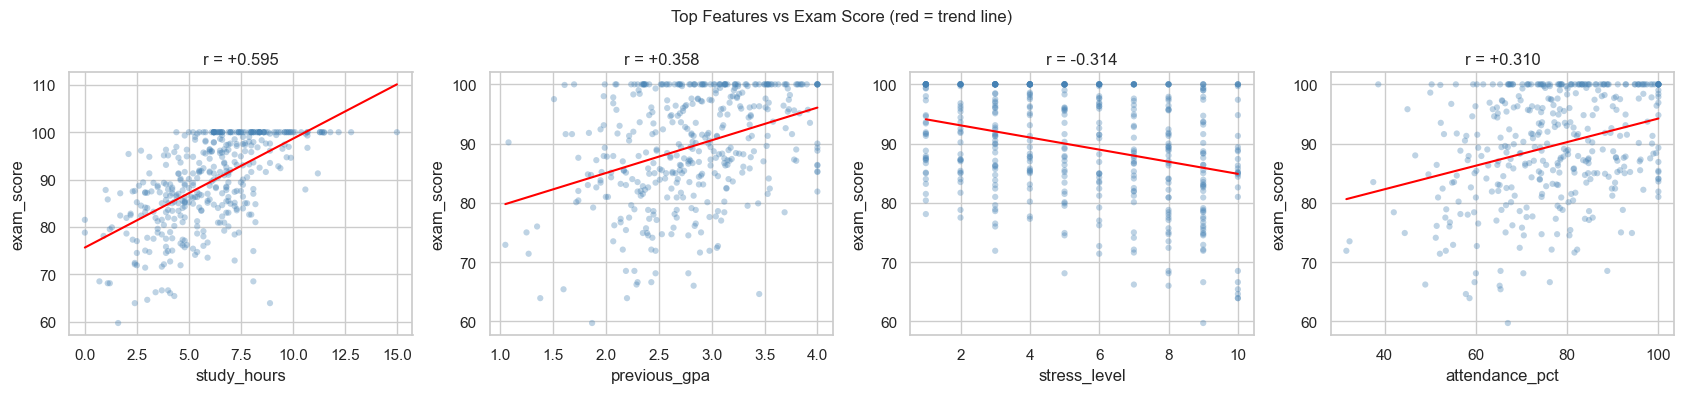

In [16]:
# Scatter plots: top 3 and bottom 1 feature vs exam_score
top_features = target_corr.index[:4].tolist()

fig, axes = plt.subplots(1, 4, figsize=(17, 4))

for ax, col in zip(axes, top_features):
    r = corr.loc[col, 'exam_score']
    ax.scatter(df[col], df['exam_score'], alpha=0.35, color='steelblue', edgecolors='none', s=20)

    # Trend line
    m_fit, b_fit = np.polyfit(df[col].dropna(), df.loc[df[col].notna(), 'exam_score'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, m_fit * x_line + b_fit, color='red', lw=1.5)

    ax.set_xlabel(col)
    ax.set_ylabel('exam_score')
    ax.set_title(f'r = {r:+.3f}')

plt.suptitle('Top Features vs Exam Score (red = trend line)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 7. Target Variable Deep Dive

Understanding `exam_score` (your target) from every angle.

In [17]:
t = df['exam_score']

print('exam_score — Full Statistical Portrait')
print('─' * 45)
print(f'  Count        : {t.count()}')
print(f'  Mean         : {t.mean():.2f}')
print(f'  Median       : {t.median():.2f}')
print(f'  Std          : {t.std():.2f}')
print(f'  Variance     : {t.var():.2f}')
print(f'  Min          : {t.min():.1f}')
print(f'  Max          : {t.max():.1f}')
print(f'  Range        : {t.max()-t.min():.1f}')
print(f'  Skewness     : {t.skew():+.3f}')
print(f'  Kurtosis     : {t.kurtosis():+.3f}')
print()
# Percentile summary
pcts = [10, 25, 50, 75, 90]
for p in pcts:
    print(f'  {p}th percentile: {np.percentile(t, p):.1f}  (bottom {p}% of students scored below this)')

exam_score — Full Statistical Portrait
─────────────────────────────────────────────
  Count        : 400
  Mean         : 89.56
  Median       : 90.15
  Std          : 9.19
  Variance     : 84.39
  Min          : 59.7
  Max          : 100.0
  Range        : 40.3
  Skewness     : -0.659
  Kurtosis     : -0.233

  10th percentile: 77.0  (bottom 10% of students scored below this)
  25th percentile: 83.8  (bottom 25% of students scored below this)
  50th percentile: 90.2  (bottom 50% of students scored below this)
  75th percentile: 98.4  (bottom 75% of students scored below this)
  90th percentile: 100.0  (bottom 90% of students scored below this)


In [18]:
# Bin exam scores into grade categories and compare feature averages
bins   = [0, 50, 65, 80, 101]
labels = ['F [0-50)', 'C [50-65)', 'B [65-80)', 'A [80-100]']
df['grade'] = pd.cut(df['exam_score'], bins=bins, labels=labels, right=False)

print('Students per grade category:')
print(df['grade'].value_counts().sort_index().to_string())
print()

# Feature averages per grade — the heart of the analysis
feature_cols = ['study_hours', 'sleep_hours', 'attendance_pct',
                'previous_gpa', 'stress_level', 'resources_used']
grade_summary = df.groupby('grade', observed=True)[feature_cols].mean().round(2)
print('Average feature values per grade group:')
print(grade_summary.to_string())

Students per grade category:
grade
F [0-50)        0
C [50-65)       4
B [65-80)      59
A [80-100]    337

Average feature values per grade group:
            study_hours  sleep_hours  attendance_pct  previous_gpa  stress_level  resources_used
grade                                                                                           
C [50-65)          3.98         6.15           61.13          2.22          9.75            3.25
B [65-80)          4.00         6.42           67.25          2.49          6.92            2.85
A [80-100]         6.44         6.82           78.67          2.89          5.12            2.99


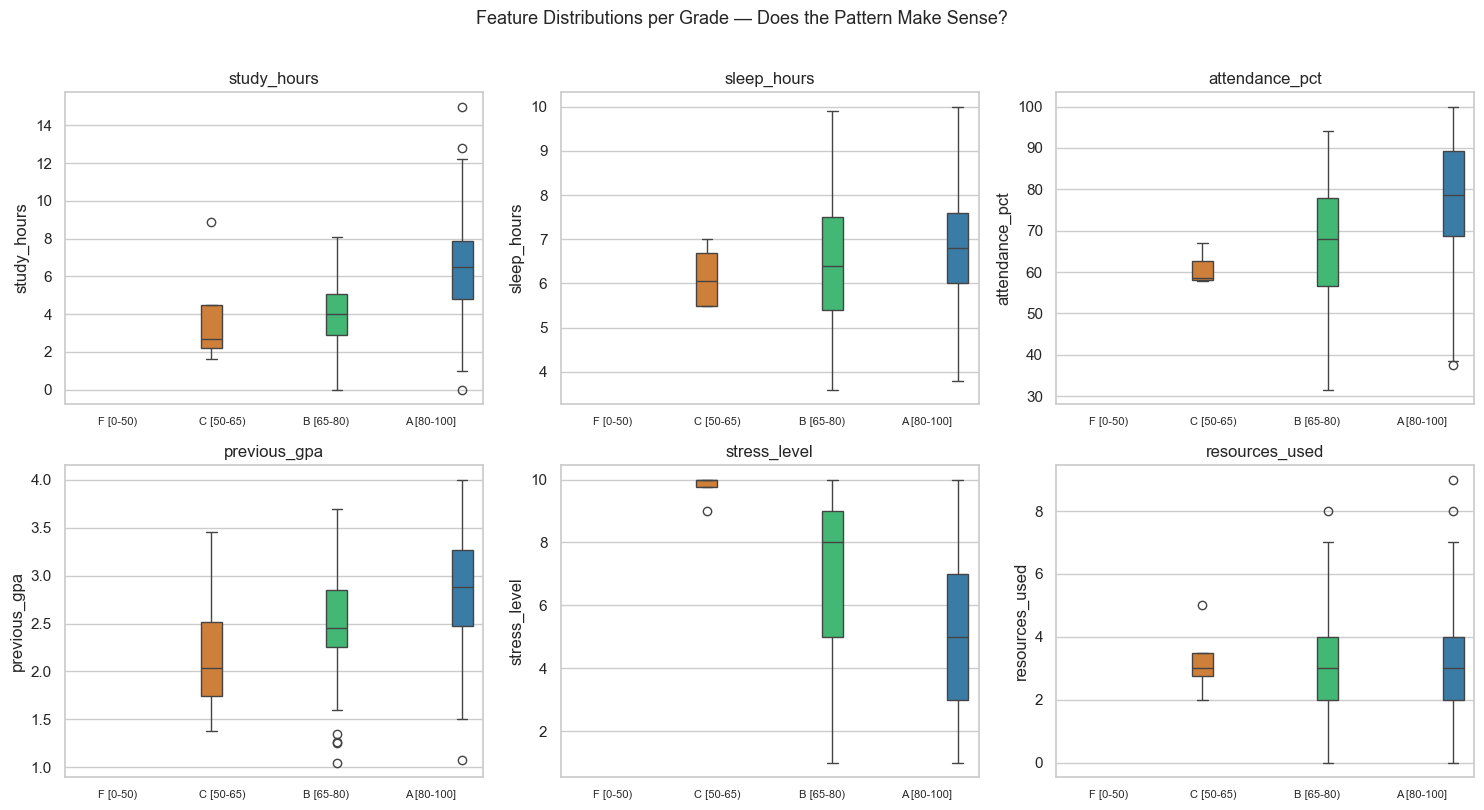


What to look for:
  study_hours / sleep_hours / previous_gpa  → should INCREASE from F to A
  stress_level                               → should DECREASE from F to A
If the pattern is reversed or random → that feature won't be useful as-is.


In [19]:
# Visualise how each feature varies across grade groups
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
palette = {'F [0-50)': '#e74c3c', 'C [50-65)': '#e67e22',
           'B [65-80)': '#2ecc71', 'A [80-100]': '#2980b9'}

for ax, col in zip(axes.flatten(), feature_cols):
    sns.boxplot(data=df, x='grade', y=col, ax=ax, palette=palette,
                order=labels, hue='grade', legend=False)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Feature Distributions per Grade — Does the Pattern Make Sense?',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print()
print('What to look for:')
print('  study_hours / sleep_hours / previous_gpa  → should INCREASE from F to A')
print('  stress_level                               → should DECREASE from F to A')
print("If the pattern is reversed or random → that feature won't be useful as-is.")

In [20]:
# Remove helper column before proceeding
df.drop(columns='grade', inplace=True)

---
## 8. Pair Plot — See Everything at Once

A pair plot shows every feature plotted against every other feature.  
The diagonal shows the individual distributions.  
This is a quick way to spot relationships, clusters, and unusual patterns.

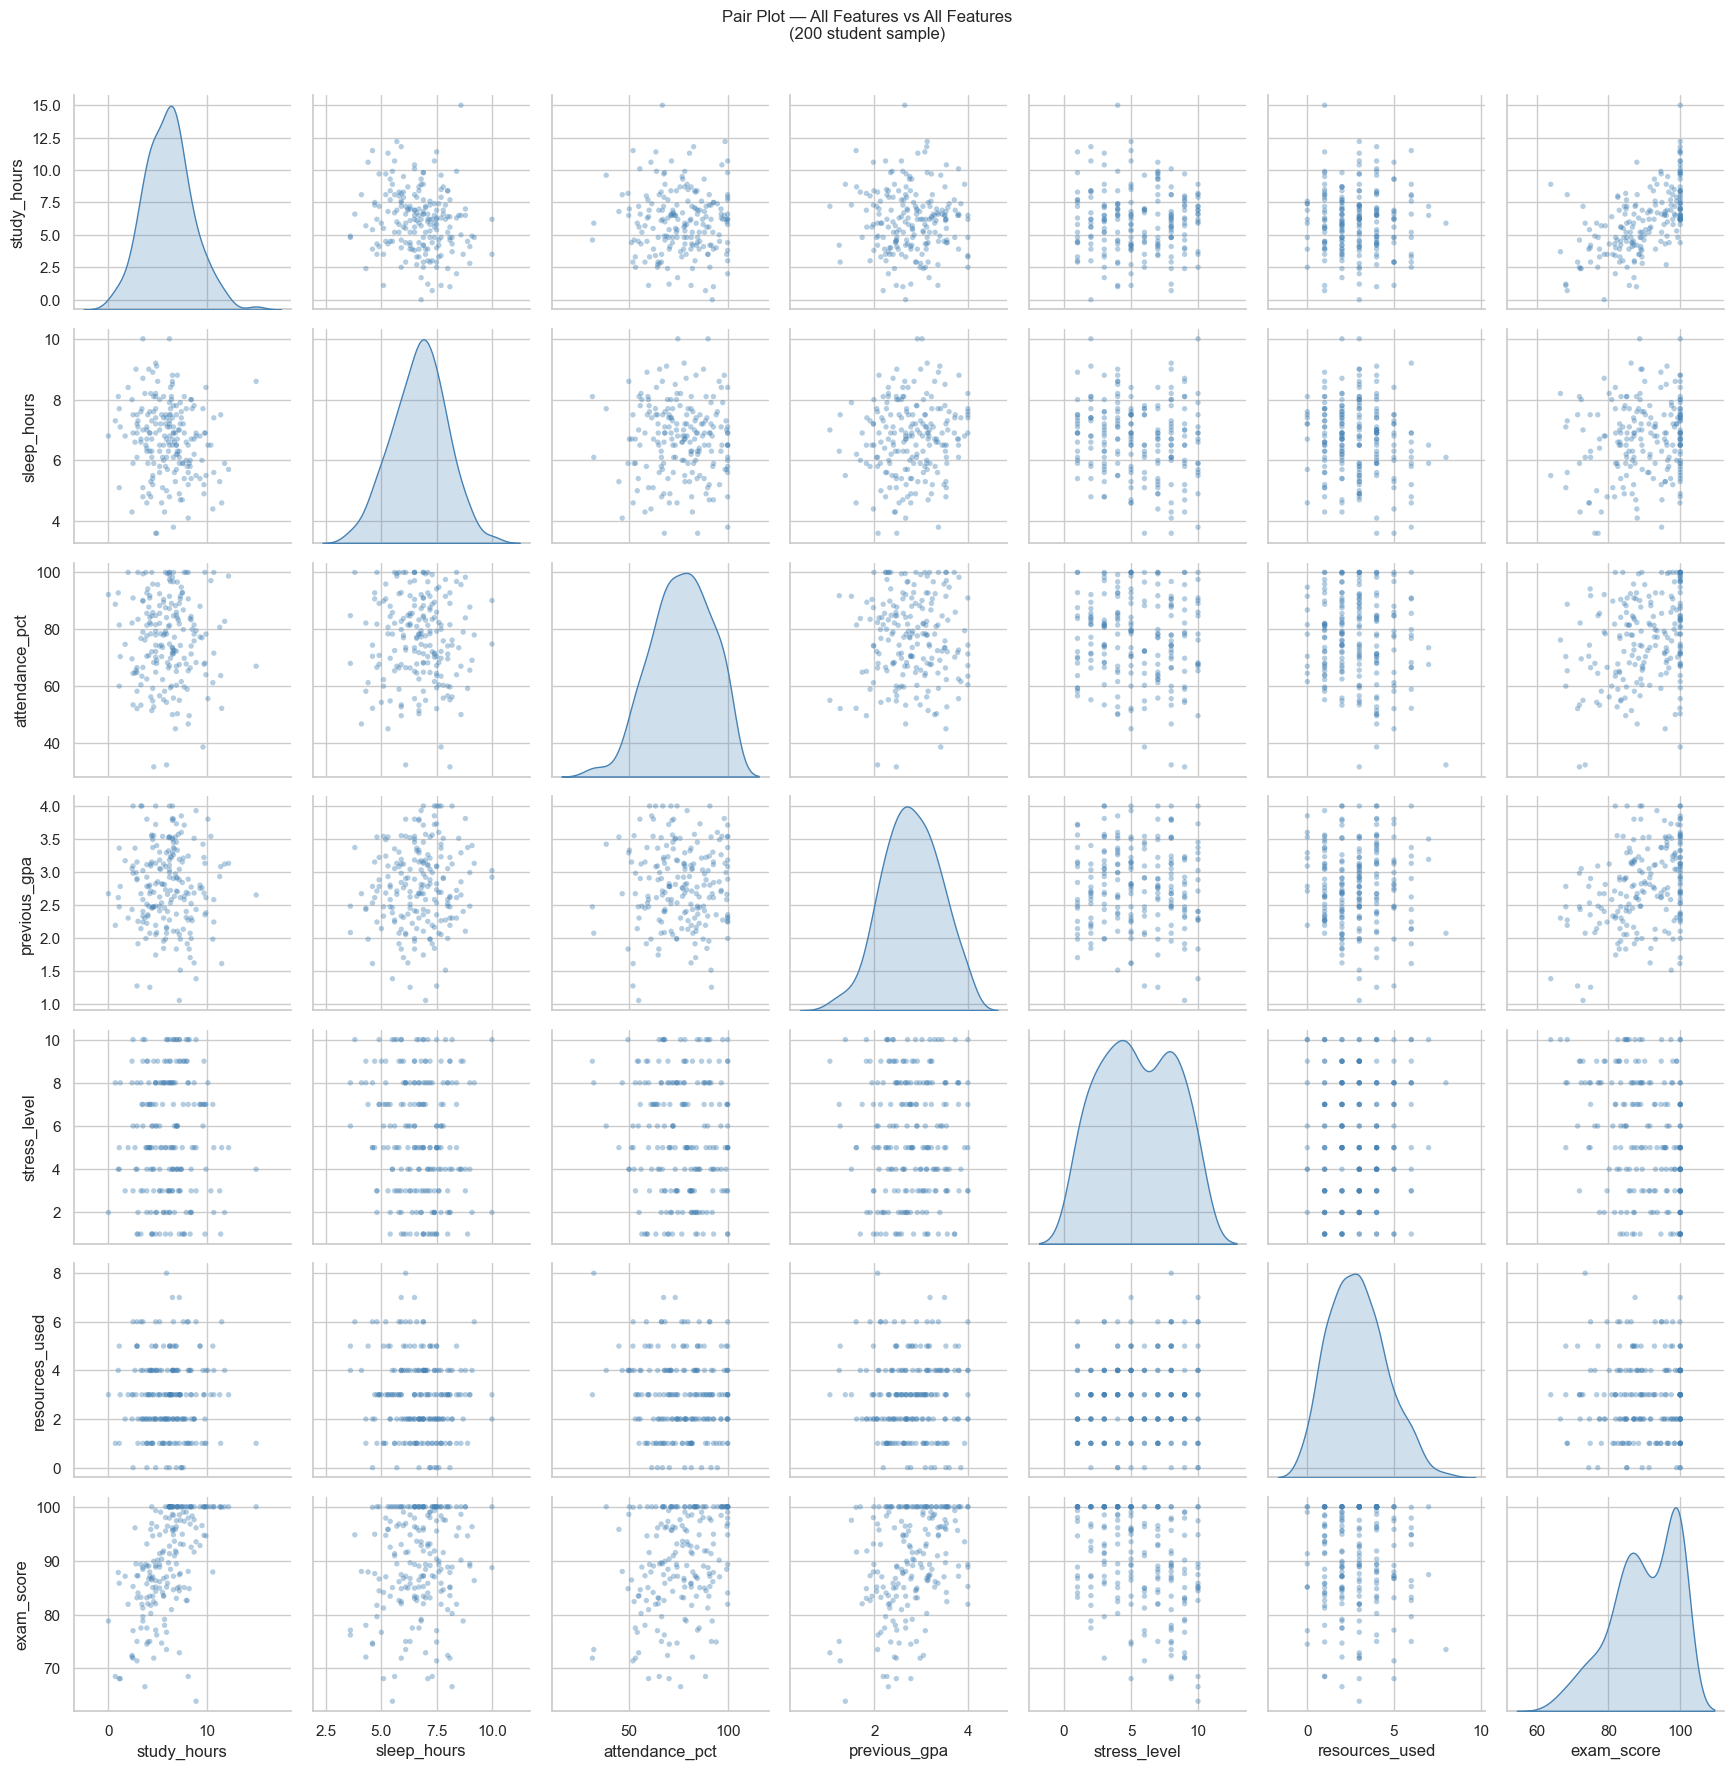

Last column/row = exam_score. Look at those for your strongest predictors.
A clear diagonal trend in a scatter = good linear relationship.
A blob with no structure           = weak relationship.


In [21]:
# Use a sample of 200 to keep it readable
sample = df[features].sample(200, random_state=42)

g = sns.pairplot(
    sample,
    diag_kind='kde',
    plot_kws=dict(alpha=0.4, s=15, edgecolors='none', color='steelblue'),
    diag_kws=dict(color='steelblue', fill=True)
)
g.figure.suptitle('Pair Plot — All Features vs All Features\n(200 student sample)',
                   y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

print('Last column/row = exam_score. Look at those for your strongest predictors.')
print('A clear diagonal trend in a scatter = good linear relationship.')
print('A blob with no structure           = weak relationship.')

---
## 9. Bias–Variance Trade-off — The Central Idea

Before building any model you need to understand the fundamental tension:

- **Bias** = how wrong is the model on average (error from wrong assumptions)
- **Variance** = how much does the model change with different training data

Total Error = Bias² + Variance + Irreducible Noise

| Scenario | What happens | Called |
|---|---|---|
| Model too simple | High bias, low variance | **Underfitting** |
| Model too complex | Low bias, high variance | **Overfitting** |
| Model just right | Balanced | **Generalisation** |

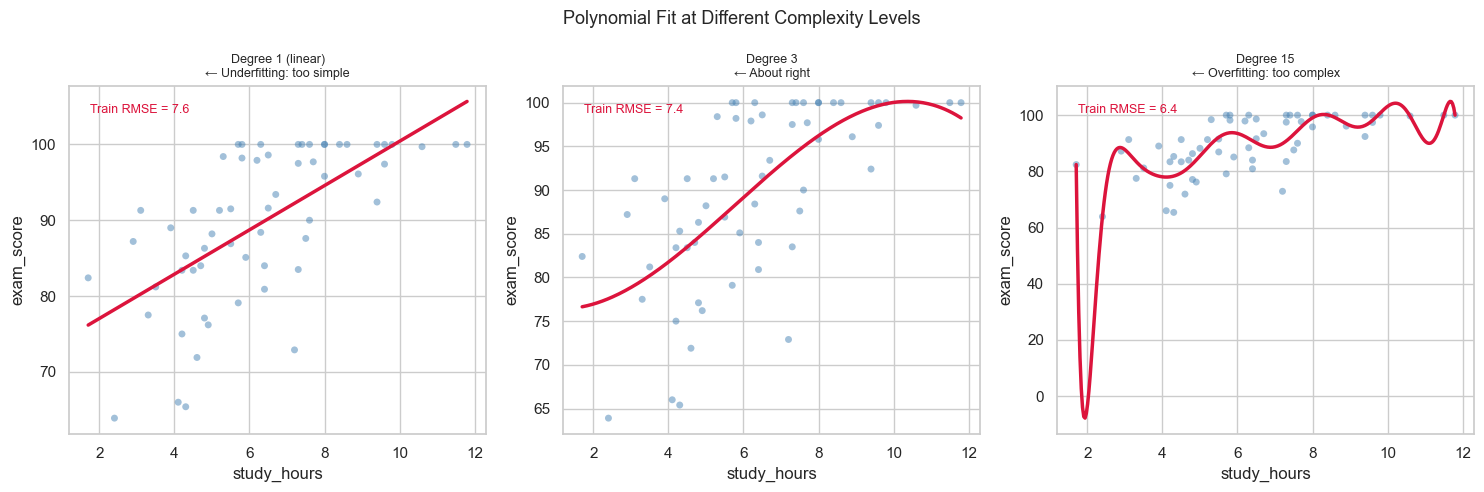

Degree 1:  line misses many points → HIGH BIAS (underfitting)
Degree 3:  reasonable fit → balanced
Degree 15: passes through almost every point → HIGH VARIANCE (overfitting)

Low train RMSE alone does NOT mean a good model.
You must test on data the model has never seen.


In [22]:
# Demonstrate underfitting vs overfitting on a tiny study_hours → exam_score slice
subset = df[['study_hours', 'exam_score']].dropna().sample(60, random_state=7)
x = subset['study_hours'].values
y = subset['exam_score'].values

x_range = np.linspace(x.min(), x.max(), 300)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = [
    'Degree 1 (linear)\n← Underfitting: too simple',
    'Degree 3\n← About right',
    'Degree 15\n← Overfitting: too complex'
]

for ax, deg, title in zip(axes, [1, 3, 15], titles):
    coeffs = np.polyfit(x, y, deg)
    poly   = np.poly1d(coeffs)

    ax.scatter(x, y, color='steelblue', alpha=0.5, s=25, edgecolors='none')
    ax.plot(x_range, poly(x_range), color='crimson', lw=2.5)

    residuals = y - poly(x)
    rmse = np.sqrt(np.mean(residuals**2))
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('study_hours')
    ax.set_ylabel('exam_score')
    ax.text(0.05, 0.92, f'Train RMSE = {rmse:.1f}', transform=ax.transAxes,
            fontsize=9, color='crimson')

plt.suptitle('Polynomial Fit at Different Complexity Levels', fontsize=13)
plt.tight_layout()
plt.show()

print('Degree 1:  line misses many points → HIGH BIAS (underfitting)')
print('Degree 3:  reasonable fit → balanced')
print('Degree 15: passes through almost every point → HIGH VARIANCE (overfitting)')
print()
print('Low train RMSE alone does NOT mean a good model.')
print('You must test on data the model has never seen.')

---
## 10. Reusable EDA Checklist Function

Copy this into any new project. Run it in the first 2 minutes after loading data.

In [23]:
def eda_report(dataframe, target=None):
    """
    One-function statistical EDA report for any tabular dataset.
    Parameters
    ----------
    dataframe : pd.DataFrame
    target    : str, optional — column name of the prediction target
    """
    SEP = '═' * 65
    numeric_cols = dataframe.select_dtypes(include='number').columns.tolist()

    # 1. Shape
    print(SEP)
    print('SHAPE')
    print(f'  Rows: {dataframe.shape[0]}   Columns: {dataframe.shape[1]}')

    # 2. Missing values
    print()
    print('MISSING VALUES')
    mv = dataframe.isnull().sum()
    if mv.any():
        for c, n in mv[mv > 0].items():
            print(f'  {c}: {n} missing ({n/len(dataframe)*100:.1f}%)')
    else:
        print('  None')

    # 3. Descriptive stats
    print()
    print('NUMERIC SUMMARY')
    print(f"  {'Column':>18}   {'Mean':>7}   {'Std':>7}   {'Skew':>7}   {'Outliers(IQR)':>14}")
    print('  ' + '─' * 60)
    for col in numeric_cols:
        s   = dataframe[col].dropna()
        sk  = s.skew()
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR = Q3 - Q1
        out = ((s < Q1 - 1.5*IQR) | (s > Q3 + 1.5*IQR)).sum()
        print(f"  {col:>18}   {s.mean():>7.2f}   {s.std():>7.2f}   {sk:>+7.2f}   {out:>14}")

    # 4. Correlation with target
    if target and target in dataframe.columns:
        print()
        print(f'CORRELATION WITH TARGET: {target}')
        c = dataframe[numeric_cols].corr()[target].drop(target).sort_values(key=abs, ascending=False)
        for col, r in c.items():
            bar = '█' * int(abs(r) * 25)
            print(f"  {col:>18}  r={r:+.3f}  {'+'if r>=0 else '-'}{bar}")

    print(SEP)


# Run it on our dataset
eda_report(df, target='exam_score')

═════════════════════════════════════════════════════════════════
SHAPE
  Rows: 400   Columns: 7

MISSING VALUES
  attendance_pct: 16 missing (4.0%)

NUMERIC SUMMARY
              Column      Mean       Std      Skew    Outliers(IQR)
  ────────────────────────────────────────────────────────────
         study_hours      6.06      2.38     +0.21                2
         sleep_hours      6.75      1.20     +0.08                4
      attendance_pct     76.84     14.28     -0.30                2
        previous_gpa      2.82      0.59     -0.10                2
        stress_level      5.43      2.81     +0.00                0
      resources_used      2.97      1.68     +0.52                3
          exam_score     89.56      9.19     -0.66                1

CORRELATION WITH TARGET: exam_score
         study_hours  r=+0.595  +██████████████
        previous_gpa  r=+0.358  +████████
        stress_level  r=-0.314  -███████
      attendance_pct  r=+0.310  +███████
         sleep_hou

---
## 11. Summary

You now have a structured way to approach any new dataset **before** feature engineering.

| Concept | Tool | Informs which FE decision |
|---|---|---|
| Mean vs Median | `.mean()` `.median()` | Which imputation strategy for missing values |
| Std / Variance | `.std()` `.var()` | Whether to standardise / normalise |
| Skewness | `.skew()` | Whether to apply log/sqrt transform |
| Kurtosis | `.kurtosis()` | How many extreme values to expect |
| IQR + Z-score | Manual + `scipy.stats` | Whether to cap or remove outliers |
| Correlation matrix | `.corr()` + heatmap | Which features to keep / drop / combine |
| Grade group analysis | `pd.cut()` + `groupby` | Whether a feature separates groups meaningfully |
| Pair plot | `sns.pairplot` | Spot non-linear relationships & clusters |
| Bias–Variance | Polynomial demo | Set model complexity expectations |
